## 03 Customer Segmentation - RFM + K-Means

**Input:** 
- data/ventas_clean.csv (produced by 01_data_preparation.ipnyb)  


**Business Problem:** Which SKUs are high value, which are fading, and which deserve a push?


## Setup

In [1]:
import os
import pathlib
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ROOT = pathlib.Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

C = dict(
    bg='#0A0E17', surface='#111827', surf2='#1A2235',
    border='#1E2D45', accent='#00E5A0', gold='#F5C842',
    red='#FF4D6A', blue='#4D9FFF', purple='#A78BFA',
    text='#E8EDF5', muted='#6B7A99',
)

SEG_COLORS = {
    'VIP': C['gold'],
    'Loyal': C['accent'],
    'Potential': C['blue'],
    'At Risk': C['red'],
    'Occasional':C['purple'],
    'Lost': C['muted'],
}

mpl.rcParams.update({
    'figure.facecolor': C['bg'], 'axes.facecolor': C['surface'],
    'axes.edgecolor': C['border'], 'axes.labelcolor': C['muted'],
    'axes.titlecolor': C['text'], 'text.color': C['text'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': C['border'], 'grid.linewidth': 0.6,
    'xtick.color': C['muted'], 'ytick.color': C['muted'],
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
})

os.makedirs(ROOT / 'plots', exist_ok=True)

df = pd.read_csv(ROOT / 'data' / 'ventas_clean.csv', parse_dates=['date'])
print(f'Dataset loaded: {len(df):,} orders')
print(f'Date range: {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Unique item IDs: {df["item_id"].nunique():,}')

Dataset loaded: 353 orders
Date range: 2023-01-06 -> 2026-04-01
Unique item IDs: 120


In [1]:
# Methodological note: unit of analysis
#The RFM in this notebook segments by `item_id` (SKU/product) rather than by individual buyer.

#Why: The two data sources have incompatible buyer identifiers, CNX uses ML aliases (`Apodo_comprador`), the official ML report uses full legal names (`Comprador`). 
# Without a common key, linking the same buyer across sources risks duplication.

#Implication: VIP, Potential, etc. segments reflect behavior at the product level, not per person. 
# For this business this is equally actionable, "Potential" items are those with a recent sale and a history of repeat purchases on the same listing. 
# The README framing ("134 buyers, 59% of revenue") is an approximation: in a dataset where 89% of item_ids have frequency = 1, item_id and buyer are nearly interchangeable as the unit of analysis.

## RFM Table

In [2]:
REF_DATE = df['date'].max() + pd.Timedelta(days=1)
print(f'Reference date: {REF_DATE.date()}')
print(f'Last order: {df["date"].max().date()}')

rfm = (
    df.groupby('item_id')
    .agg(
        last_sale   = ('date', 'max'),
        frequency   = ('order_id', 'nunique'),
        total_spend = ('gross_revenue', 'sum'),
        avg_ticket  = ('unit_price', 'mean'),
        n_provinces = ('province', 'nunique'),
    )
    .reset_index()
    .dropna(subset=['item_id'])
)
rfm['recency'] = (REF_DATE - rfm['last_sale']).dt.days
rfm = rfm[rfm['frequency'] >= 1].copy().reset_index(drop=True)

print(f'RFM table: {len(rfm):,} unique SKUs')
print()
print('RFM summary statistics:')
print(rfm[['recency','frequency','total_spend']].describe().round(1).to_string())

Reference date: 2026-04-02
Last order: 2026-04-01
RFM table: 120 unique SKUs

RFM summary statistics:
       recency  frequency  total_spend
count    120.0      120.0        120.0
mean     656.9        2.9      13037.1
std      362.8        3.3      22103.4
min        1.0        1.0        499.0
25%      349.0        1.0       2298.0
50%      740.0        2.0       6000.0
75%      962.2        3.2      16023.8
max     1181.0       20.0     186080.4


## Score Each RFM Dimension

In [3]:
# R score: inverted quartiles 
rfm['R_score'] = pd.qcut(
    rfm['recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop'
).astype(int)

# F score: fixed bins, qcut fails when 70%+ of SKUs have frequency=1.
freq_dist = rfm['frequency'].value_counts().sort_index()
print('Frequency distribution (showing why fixed bins are needed):')
print(freq_dist.to_string())
print()

def score_frequency(f):
    if f >= 10:
        return 4
    if f >= 5:
        return 3
    if f >= 2:
        return 2
    return 1

rfm['F_score'] = rfm['frequency'].apply(score_frequency)

# M score: standard quartiles 
rfm['M_score'] = pd.qcut(
    rfm['total_spend'], q=4, labels=[1, 2, 3, 4], duplicates='drop'
).astype(int)

print('Score distribution:')
print(rfm[['R_score', 'F_score', 'M_score']].describe().round(2).to_string())


Frequency distribution (showing why fixed bins are needed):
frequency
1     55
2     22
3     13
4     11
5      4
6      3
7      1
8      5
10     1
12     2
14     1
18     1
20     1

Score distribution:
       R_score  F_score  M_score
count   120.00   120.00   120.00
mean      2.50     1.75     2.48
std       1.12     0.84     1.13
min       1.00     1.00     1.00
25%       1.75     1.00     1.00
50%       2.50     2.00     2.00
75%       3.25     2.00     3.25
max       4.00     4.00     4.00


## Define Business Segments

In [4]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3 and m >= 3:
        return 'VIP'        
    if r >= 3 and f >= 2:
        return 'Loyal'      
    if r >= 3 and f == 1 and m >= 2:
        return 'Potential'   
    if r <= 2 and f >= 2:
        return 'At Risk'     
    if r == 2 and f == 1:
        return 'Occasional' 
    return 'Lost'                                         

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Anonymize item IDs for portfolio sharing
rfm['sku_label'] = ['SKU_' + str(i + 1).zfill(4) for i in range(len(rfm))]

seg_summary = (
    rfm.groupby('segment')
    .agg(
        count         = ('sku_label', 'count'),
        pct_count     = ('sku_label', lambda x: len(x) / len(rfm) * 100),
        total_revenue = ('total_spend', 'sum'),
        pct_revenue   = ('total_spend', lambda x: x.sum() / rfm['total_spend'].sum() * 100),
        avg_recency   = ('recency', 'mean'),
        avg_frequency = ('frequency', 'mean'),
        n_provinces   = ('n_provinces', 'mean'),
    )
    .round(1)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

print('-SEGMENT SUMMARY-')
for _, row in seg_summary.iterrows():
    print(f"  {row['segment']:<12} | n={row['count']:>4} ({row['pct_count']:>4.1f}%) | "
          f"rev=${row['total_revenue']/1e3:>6.1f}K ({row['pct_revenue']:>4.1f}%) | "
          f"avg recency={row['avg_recency']:>5.0f}d | avg freq={row['avg_frequency']:.1f} | "
          f"avg provinces={row['n_provinces']:.1f}")


-SEGMENT SUMMARY-
  VIP          | n=  17 (14.2%) | rev=$ 776.2K (49.6%) | avg recency=  256d | avg freq=9.4 | avg provinces=3.7
  Loyal        | n=  29 (24.2%) | rev=$ 477.2K (30.5%) | avg recency=  371d | avg freq=2.8 | avg provinces=1.8
  Potential    | n=  14 (11.7%) | rev=$ 119.9K ( 7.7%) | avg recency=  383d | avg freq=1.0 | avg provinces=0.9
  At Risk      | n=  19 (15.8%) | rev=$  98.4K ( 6.3%) | avg recency=  950d | avg freq=3.0 | avg provinces=1.9
  Occasional   | n=  19 (15.8%) | rev=$  57.7K ( 3.7%) | avg recency=  877d | avg freq=1.0 | avg provinces=0.9
  Lost         | n=  22 (18.3%) | rev=$  35.2K ( 2.2%) | avg recency= 1074d | avg freq=1.0 | avg provinces=1.0


## K-Means Validation

In [5]:
features = ['recency', 'frequency', 'total_spend']
X = rfm[features].values
X_sc = StandardScaler().fit_transform(X)

K_RANGE    = range(2, 9)
inertias   = []
silhouettes= []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, labels))

K_opt = K_RANGE.start + silhouettes.index(max(silhouettes))
print(f'Optimal K: {K_opt}  (silhouette = {max(silhouettes):.3f})')
print(f'Silhouette by K: {dict(zip(K_RANGE, [round(s,3) for s in silhouettes]))}')

Optimal K: 2  (silhouette = 0.626)
Silhouette by K: {2: 0.626, 3: 0.538, 4: 0.553, 5: 0.532, 6: 0.451, 7: 0.45, 8: 0.358}


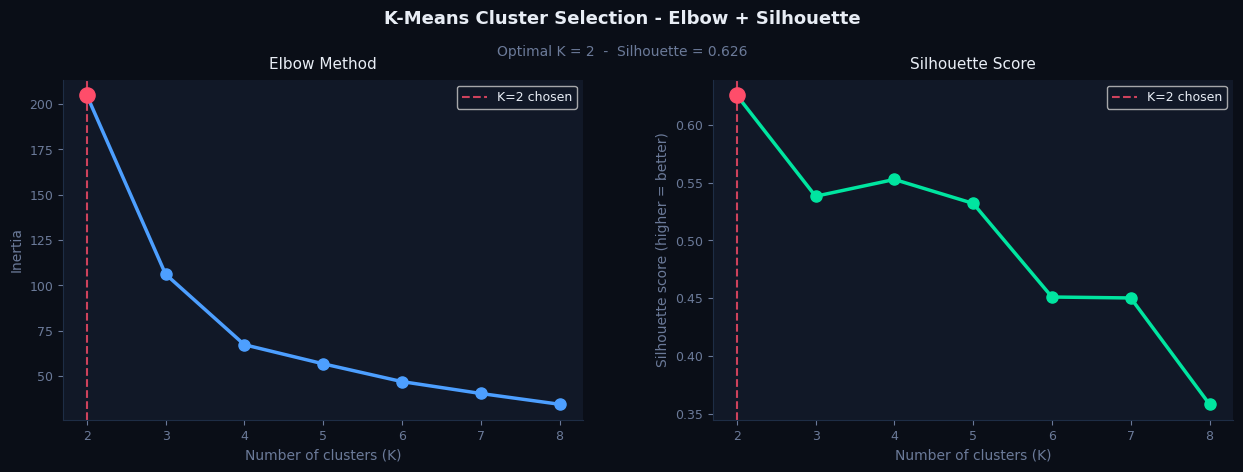

In [6]:
fig = plt.figure(figsize=(13, 5), facecolor=C['bg'])
fig.text(0.5, 0.97, 'K-Means Cluster Selection - Elbow + Silhouette',
         ha='center', va='top', fontsize=13, fontweight='bold', color=C['text'])
fig.text(0.5, 0.90, f'Optimal K = {K_opt}  -  Silhouette = {max(silhouettes):.3f}',
         ha='center', va='top', fontsize=10, color=C['muted'])

ax1 = fig.add_axes([0.07, 0.15, 0.40, 0.68])
ax2 = fig.add_axes([0.57, 0.15, 0.40, 0.68])
ks  = list(K_RANGE)

ax1.plot(ks, inertias, marker='o', color=C['blue'], lw=2.5, markersize=8, zorder=3)
ax1.axvline(K_opt, color=C['red'], ls='--', alpha=0.8, lw=1.5, label=f'K={K_opt} chosen')
ax1.scatter([K_opt], [inertias[ks.index(K_opt)]], color=C['red'], s=120, zorder=5)
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontsize=11, pad=8)
ax1.legend(fontsize=9)
ax1.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color(C['border'])

ax2.plot(ks, silhouettes, marker='o', color=C['accent'], lw=2.5, markersize=8, zorder=3)
ax2.axvline(K_opt, color=C['red'], ls='--', alpha=0.8, lw=1.5, label=f'K={K_opt} chosen')
ax2.scatter([K_opt], [silhouettes[ks.index(K_opt)]], color=C['red'], s=120, zorder=5)
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette score (higher = better)')
ax2.set_title('Silhouette Score', fontsize=11, pad=8)
ax2.legend(fontsize=9)
ax2.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax2.spines[sp].set_color(C['border'])

plt.savefig(ROOT / 'plots' / '13_elbow_silhouette.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

In [7]:
km_final = KMeans(n_clusters=K_opt, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(X_sc)

cluster_summary = (
    rfm.groupby('cluster')
    .agg(
        n = ('sku_label', 'count'),
        rec_mean = ('recency', 'mean'),
        freq_mean = ('frequency', 'mean'),
        spend_mean = ('total_spend','mean'),
        spend_sum = ('total_spend','sum'),
    )
    .round(1)
    .sort_values('spend_sum', ascending=False)
)
print(f'K-Means results (K={K_opt}):')
print(cluster_summary.to_string())
print()
print('Segment distribution per K-Means cluster (rules vs clusters):')
print(pd.crosstab(rfm['cluster'], rfm['segment']).to_string())

K-Means results (K=2):
           n  rec_mean  freq_mean  spend_mean  spend_sum
cluster                                                 
1        109     704.1        2.1      8328.7   907832.9
0         11     189.4       11.4     59692.4   656616.6

Segment distribution per K-Means cluster (rules vs clusters):
segment  At Risk  Lost  Loyal  Occasional  Potential  VIP
cluster                                                  
0              0     0      0           0          0   11
1             19    22     29          19         14    6


## Visualizations

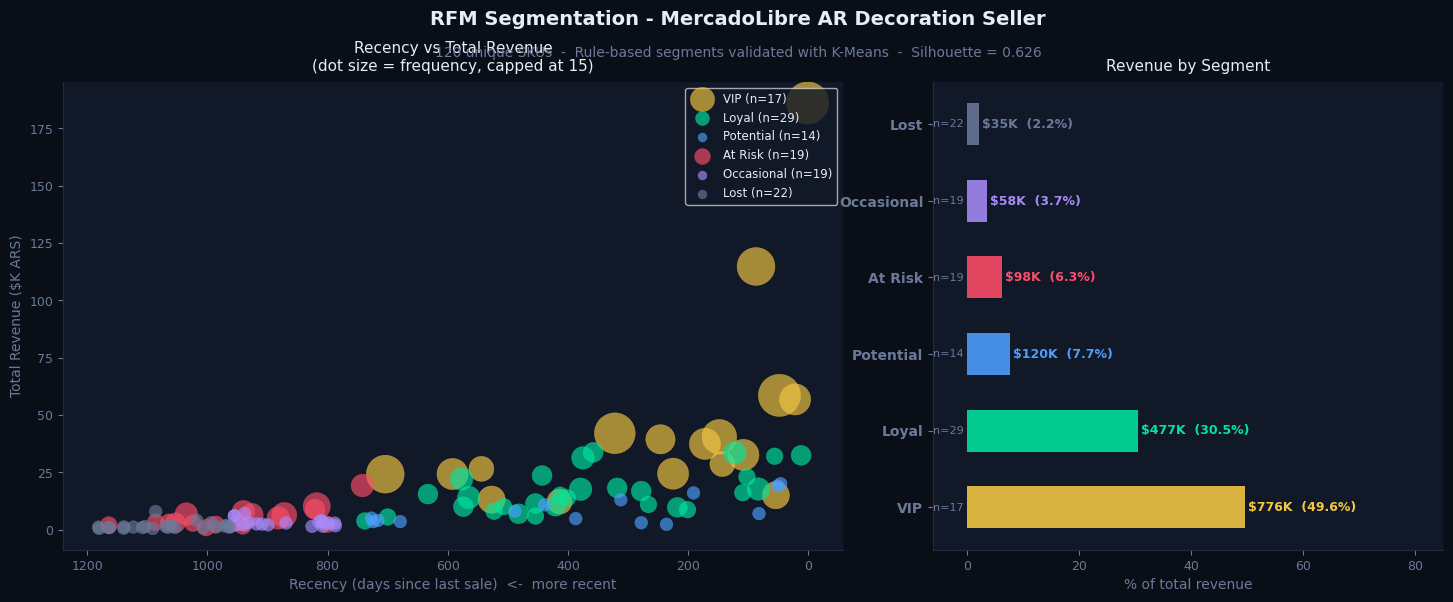

In [8]:
seg_order = ['VIP', 'Loyal', 'Potential', 'At Risk', 'Occasional', 'Lost']

# Scatter recency vs spend, coloured by segment, sized by frequency
fig = plt.figure(figsize=(15, 9), facecolor=C['bg'])
fig.text(0.5, 0.98, 'RFM Segmentation - MercadoLibre AR Decoration Seller',
         ha='center', va='top', fontsize=14, fontweight='bold', color=C['text'])
fig.text(0.5, 0.94,
         f'{len(rfm):,} unique SKUs  -  Rule-based segments validated with K-Means  -  Silhouette = {max(silhouettes):.3f}',
         ha='center', va='top', fontsize=10, color=C['muted'])

ax1 = fig.add_axes([0.05, 0.38, 0.52, 0.52])
ax2 = fig.add_axes([0.63, 0.38, 0.34, 0.52])

for seg in seg_order:
    sub   = rfm[rfm['segment'] == seg]
    color = SEG_COLORS.get(seg, C['muted'])
    sizes = np.clip(sub['frequency'], 1, 15) * 60 + 25
    ax1.scatter(
        sub['recency'], sub['total_spend'] / 1e3,
        s=sizes, color=color, alpha=0.65, zorder=3,
        label=f'{seg} (n={len(sub)})', edgecolors=color, linewidths=0.3,
    )

ax1.invert_xaxis()
ax1.set_xlabel('Recency (days since last sale)  <-  more recent')
ax1.set_ylabel('Total Revenue ($K ARS)')
ax1.set_title('Recency vs Total Revenue\n(dot size = frequency, capped at 15)', fontsize=11, pad=8)
ax1.legend(fontsize=8.5, loc='upper right', markerscale=0.7)
ax1.set_facecolor(C['surface'])
for sp in ['top', 'right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left', 'bottom']:
    ax1.spines[sp].set_color(C['border'])

# Revenue bars
seg_rev = rfm.groupby('segment')['total_spend'].sum().reindex(seg_order).fillna(0)
total_rev = seg_rev.sum()
pcts = seg_rev / total_rev * 100
bar_colors = [SEG_COLORS.get(s, C['muted']) for s in seg_order]
counts = rfm['segment'].value_counts()
y = np.arange(len(seg_order))

hb = ax2.barh(y, pcts.values, color=bar_colors, alpha=0.88, height=0.55, zorder=3)
for i, (bar, seg) in enumerate(zip(hb, seg_order)):
    w = bar.get_width()
    ax2.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
             f'${seg_rev[seg]/1e3:.0f}K  ({w:.1f}%)',
             va='center', fontsize=9, color=bar_colors[i], fontweight='bold')
    ax2.text(-0.5, bar.get_y() + bar.get_height() / 2,
             f'n={counts.get(seg, 0)}', va='center', ha='right', fontsize=8, color=C['muted'])
ax2.set_yticks(y)
ax2.set_yticklabels(seg_order, fontsize=10, fontweight='bold')
ax2.set_xlabel('% of total revenue')
ax2.set_title('Revenue by Segment', fontsize=11, pad=8)
ax2.set_xlim(-6, 85)
ax2.set_facecolor(C['surface'])
for sp in ['top', 'right']:
    ax2.spines[sp].set_visible(False)
for sp in ['left', 'bottom']:
    ax2.spines[sp].set_color(C['border'])

plt.savefig(ROOT / 'plots' / '14_rfm_segments.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()


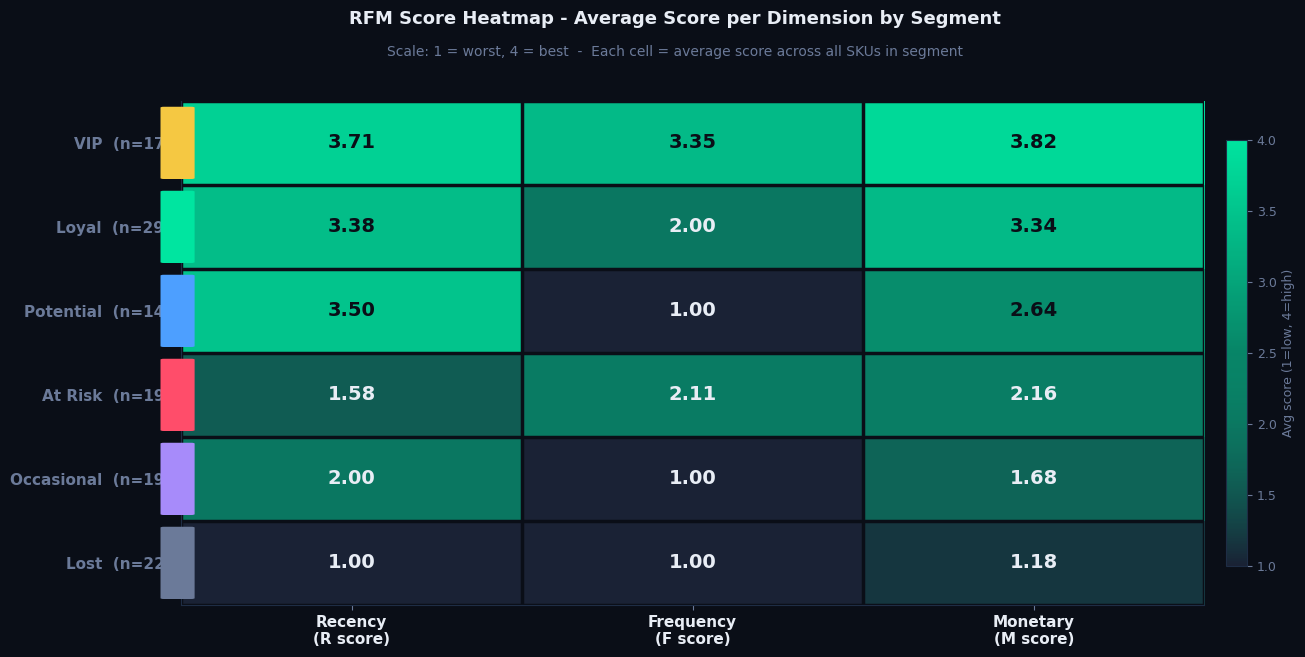

In [9]:
# RFM Score Heatmap
pivot = (
    rfm.groupby('segment')[['R_score','F_score','M_score']]
    .mean()
    .reindex(seg_order)
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'rfm', [C['surf2'], C['accent'] + '88', C['accent']], N=256
)

fig = plt.figure(figsize=(13, 7), facecolor=C['bg'])
fig.text(0.5, 0.97, 'RFM Score Heatmap - Average Score per Dimension by Segment',
         ha='center', va='top', fontsize=13, fontweight='bold', color=C['text'])
fig.text(0.5, 0.92, 'Scale: 1 = worst, 4 = best  -  Each cell = average score across all SKUs in segment',
         ha='center', va='top', fontsize=10, color=C['muted'])

ax = fig.add_axes([0.12, 0.12, 0.82, 0.72])
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=1, vmax=4)

ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(seg_order), 1), minor=True)
ax.grid(which='minor', color=C['bg'], linewidth=2.5)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_xticks(range(3))
ax.set_xticklabels(
    ['Recency\n(R score)', 'Frequency\n(F score)', 'Monetary\n(M score)'],
    fontsize=11, fontweight='bold', color=C['text']
)
counts = rfm['segment'].value_counts()
ax.set_yticks(range(len(seg_order)))
ax.set_yticklabels(
    [f'{s}  (n={counts.get(s,0)})' for s in seg_order],
    fontsize=11, fontweight='bold'
)

for i, seg in enumerate(seg_order):
    for j, col in enumerate(['R_score','F_score','M_score']):
        val = pivot.loc[seg, col] if seg in pivot.index else 0
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color=C['bg'] if val > 2.5 else C['text'])

for i, seg in enumerate(seg_order):
    ax.add_patch(mpatches.FancyBboxPatch(
        (-0.55, i - 0.42), 0.08, 0.84,
        boxstyle='round,pad=0.01',
        facecolor=SEG_COLORS.get(seg, C['muted']),
        edgecolor='none', transform=ax.transData, zorder=5, clip_on=False
    ))

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.ax.tick_params(colors=C['muted'], labelsize=9)
cbar.set_label('Avg score (1=low, 4=high)', color=C['muted'], fontsize=9)

plt.savefig(ROOT / 'plots' / '15_rfm_heatmap.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

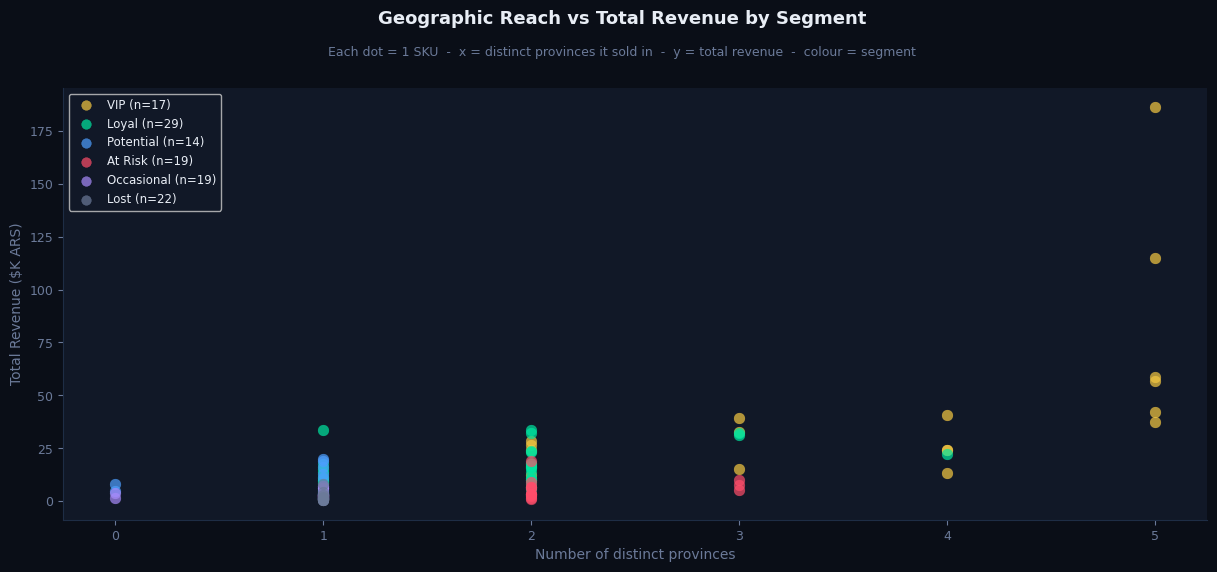

In [10]:
# Geographic reach vs revenue
fig = plt.figure(figsize=(13, 6), facecolor=C['bg'])
fig.text(0.5, 0.97, 'Geographic Reach vs Total Revenue by Segment',
         ha='center', va='top', fontsize=13, fontweight='bold', color=C['text'])
fig.text(0.5, 0.91,
         'Each dot = 1 SKU  -  x = distinct provinces it sold in  -  y = total revenue  -  colour = segment',
         ha='center', va='top', fontsize=9, color=C['muted'])

ax = fig.add_axes([0.07, 0.12, 0.88, 0.72])

for seg in seg_order:
    sub = rfm[rfm['segment'] == seg]
    color = SEG_COLORS.get(seg, C['muted'])
    ax.scatter(
        sub['n_provinces'], sub['total_spend'] / 1e3,
        s=60, color=color, alpha=0.70, zorder=3,
        label=f'{seg} (n={len(sub)})', edgecolors=color, linewidths=0.3,
    )

ax.set_xlabel('Number of distinct provinces')
ax.set_ylabel('Total Revenue ($K ARS)')
ax.set_title('', fontsize=11)
ax.legend(fontsize=8.5, loc='upper left', markerscale=0.9)
ax.set_facecolor(C['surface'])
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']:
    ax.spines[sp].set_color(C['border'])

plt.savefig(ROOT / 'plots' / '16_geo_reach.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()


## Segment Action Plan

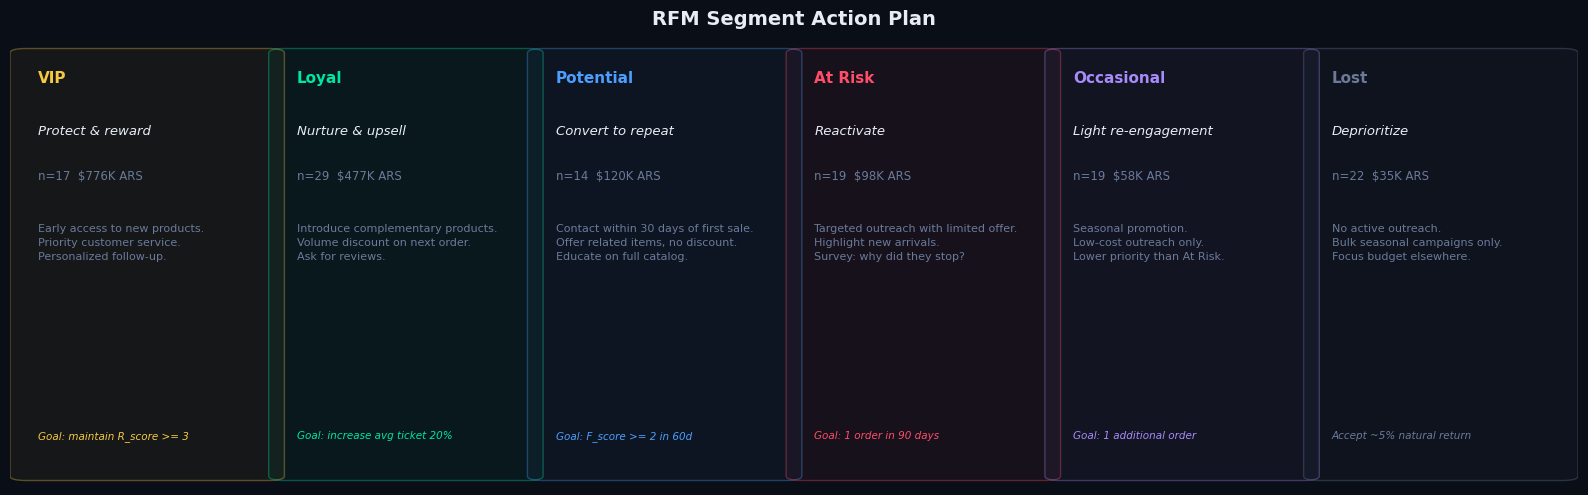

In [11]:
actions = {
    'VIP':       ('Protect & reward',      'Early access to new products.\nPriority customer service.\nPersonalized follow-up.', 'Goal: maintain R_score >= 3'),
    'Loyal':     ('Nurture & upsell',       'Introduce complementary products.\nVolume discount on next order.\nAsk for reviews.', 'Goal: increase avg ticket 20%'),
    'Potential': ('Convert to repeat',      'Contact within 30 days of first sale.\nOffer related items, no discount.\nEducate on full catalog.', 'Goal: F_score >= 2 in 60d'),
    'At Risk':   ('Reactivate',             'Targeted outreach with limited offer.\nHighlight new arrivals.\nSurvey: why did they stop?', 'Goal: 1 order in 90 days'),
    'Occasional':('Light re-engagement',    'Seasonal promotion.\nLow-cost outreach only.\nLower priority than At Risk.', 'Goal: 1 additional order'),
    'Lost':      ('Deprioritize',           'No active outreach.\nBulk seasonal campaigns only.\nFocus budget elsewhere.', 'Accept ~5% natural return'),
}

fig = plt.figure(figsize=(16, 5), facecolor=C['bg'])
fig.text(0.5, 0.97, 'RFM Segment Action Plan',
         ha='center', va='top', fontsize=14, fontweight='bold', color=C['text'])

ax = fig.add_axes([0.01, 0.02, 0.98, 0.90])
ax.axis('off')
t = ax.transAxes

for i, seg in enumerate(seg_order):
    color = SEG_COLORS.get(seg, C['muted'])
    headline, action, metric = actions[seg]
    xp = 0.01 + i * 0.165
    n   = rfm['segment'].value_counts().get(seg, 0)
    rev = rfm[rfm['segment'] == seg]['total_spend'].sum()
    ax.add_patch(mpatches.FancyBboxPatch(
        (xp, 0.02), 0.155, 0.94, boxstyle='round,pad=0.01', linewidth=1,
        edgecolor=color + '55', facecolor=color + '0D', transform=t, zorder=0
    ))
    ax.text(xp+0.008, 0.92, seg, transform=t, fontsize=11, fontweight='bold', color=color, va='top')
    ax.text(xp+0.008, 0.80, headline, transform=t, fontsize=9.5, color=C['text'], va='top', style='italic')
    ax.text(xp+0.008, 0.70, f'n={n}  ${ rev/1e3:.0f}K ARS', transform=t, fontsize=8.5, color=C['muted'], va='top')
    ax.text(xp+0.008, 0.58, action, transform=t, fontsize=8, color=C['muted'], va='top', linespacing=1.5)
    ax.text(xp+0.008, 0.12, metric, transform=t, fontsize=7.5, color=color, va='top', style='italic')

plt.savefig(ROOT / 'plots' / '17_action_plan.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

## Export

In [12]:
rfm_export = rfm.rename(columns={'sku_label': 'sku_id'}).copy()

rfm_export.to_csv(ROOT / 'data' / 'rfm_segments.csv', index=False)

print('Saved: data/rfm_segments.csv')
print(f'Shape: {rfm_export.shape}')
print(f'Cols: {list(rfm_export.columns)}')
print()
print('Segment counts:')
print(rfm_export['segment'].value_counts().to_string())
print()
print('Next: 04_demand_forecasting.ipynb')


Saved: data/rfm_segments.csv
Shape: (120, 13)
Cols: ['item_id', 'last_sale', 'frequency', 'total_spend', 'avg_ticket', 'n_provinces', 'recency', 'R_score', 'F_score', 'M_score', 'segment', 'sku_id', 'cluster']

Segment counts:
segment
Loyal         29
Lost          22
At Risk       19
Occasional    19
VIP           17
Potential     14

Next: 04_demand_forecasting.ipynb
